In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from eomaps import Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.path import shapely_to_path
from shapely.ops import unary_union
import geopandas as gpd
import os

%matplotlib widget

In [ ]:
for file in os.listdir("C:/Users/ottos/Documents/Geomatik/2. Sem/AICoding/data/gkgcounts"):
    print(file)

gkg = pd.read_csv("C:/Users/ottos/Documents/Geomatik/2. Sem/AICoding/data/20260308.gkgcounts.csv/20260308.gkgcounts.csv", header=0, delimiter="\t")


gkg.dropna(subset=["GEO_LAT", "GEO_LONG"], inplace=True)
gkg

,DATE,NUMARTS,COUNTTYPE,NUMBER,OBJECTTYPE,GEO_TYPE,GEO_FULLNAME,GEO_COUNTRYCODE,GEO_ADM1CODE,GEO_LAT,GEO_LONG,GEO_FEATUREID,CAMEOEVENTIDS,SOURCES,SOURCEURLS
1,20260308,1,KIDNAP,110,pupils,4,"Chibok, Borno, Nigeria",NI,NI27,10.8658,12.8470,-2003729,"1293038465,1293038471,1293038475",punchng.com,https://punchng.com/iwd-2026-ensuring-rights-e...
2,20260308,1,AFFECT,200,tenants,1,United Kingdom,UK,UK,54.0000,-4.0000,UK,"1293054830,1293055008,1293055015,1293055068,12...",dailypakistan.com.pk,https://en.dailypakistan.com.pk/07-Mar-2026/lo...
3,20260308,1,CRISISLEX_CRISISLEXREC,2,men,2,"Utah, United States",US,USUT,40.1135,-111.8540,UT,NaN,nonpareilonline.com,https://nonpareilonline.com/news/state-regiona...
4,20260308,2,DISPLACED,20000,NaN,1,United Arab Emirates,AE,AE,24.0000,54.0000,AE,"1291653869,1293047474,1291712276,1291631894,12...",kens5.com;wsbradio.com,https://www.kens5.com/article/syndication/asso...
6,20260308,1,CRISISLEX_T03_DEAD,79,NaN,1,United Kingdom,UK,UK,54.0000,-4.0000,UK,NaN,northwichguardian.co.uk,https://www.northwichguardian.co.uk/news/25913...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12927,20260308,2,KILL,10,NaN,1,Syria,SY,SY,35.0000,38.0000,SY,"1293105048,1293105049,1293105050,1293069853,12...",breitbart.com;antonyloewenstein.com,https://www.breitbart.com/politics/2026/03/07/...
12928,20260308,1,KILL,103,NaN,4,"Patna, Bihar, India",IN,IN34,25.6000,85.1167,-2107500,"1293100256,1293100435,1293100462,1293100468,12...",siasat.com,https://www.siasat.com/bihar-woman-fasting-for...
12929,20260308,4,KILL,3,NaN,1,Kuwait,KU,KU,29.5000,47.7500,KU,"1293033364,1293033087,1293033626,1293029099,12...",indiatimes.com;sputnikglobe.com;yahoo.com;task...,https://economictimes.indiatimes.com/news/defe...
12930,20260308,2,CRISISLEX_CRISISLEXREC,200,NaN,1,Nepal,NP,NP,28.0000,84.0000,NP,"1293117260,1293124590,1293124625,1293124626,12...",sky.com;cbc.ca,https://news.sky.com/story/rapper-and-gen-z-pr...


In [17]:
extract = gkg[["NUMARTS", "GEO_LAT", "GEO_LONG"]]
extract

,NUMARTS,GEO_LAT,GEO_LONG
1,1,10.8658,12.8470
2,1,54.0000,-4.0000
3,1,40.1135,-111.8540
4,2,24.0000,54.0000
6,1,54.0000,-4.0000
...,...,...,...
12927,2,35.0000,38.0000
12928,1,25.6000,85.1167
12929,4,29.5000,47.7500
12930,2,28.0000,84.0000


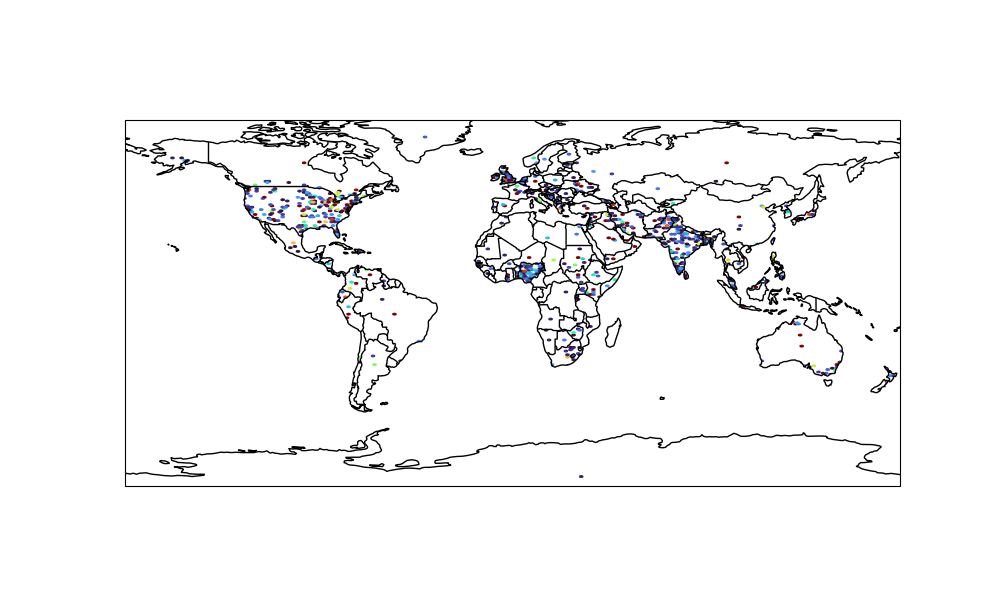

In [18]:
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS)

hb = ax.hexbin(
    extract["GEO_LONG"], extract["GEO_LAT"],
    C=extract["NUMARTS"],
    reduce_C_function=sum,
    gridsize=240,
    vmax=50,
    cmap="turbo"
)

land = cfeature.NaturalEarthFeature("physical", "land", "110m")
land_geom = unary_union(list(land.geometries()))
land_path = shapely_to_path(land_geom)

clip_patch = mpatches.PathPatch(
    land_path,
    transform=ccrs.PlateCarree()._as_mpl_transform(ax)
)

hb.set_clip_path(clip_patch)

#plt.colorbar(hb, label="Count per hexagon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [20]:
for i in range(1,22):
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
